# RQ2 — Demand Forecasting: Predicting Total Medicare Discharges
### DSCI 5260 — Group 6 | Medicare Inpatient Utilization and Payment Analysis

**Research Question:** Can we predict the total number of Medicare discharges (patient volume) for a given hospital–DRG combination based on hospital characteristics, DRG complexity, and geographic factors?

**Target Variable:** `Log_Tot_Dschrgs` (log1p-transformed total discharges)

**Sections:**
- **4.1** Load Data & Define Feature Set
- **4.2** Baseline Model — Linear Regression
- **4.3** Random Forest Regressor
- **4.4** XGBoost Regressor
- **4.5** Model Comparison
- **4.6** Feature Importance & SHAP Analysis
- **4.7** Final Evaluation on Test Set
- **4.8** Business Insights

> **Input:** `df_train.parquet`, `df_val.parquet`, `df_test.parquet` from `Data/Processed_Data/`  
> **Output:** Best model predictions and feature importance findings

---
## 4.1 Load Data & Define Feature Set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb

PROCESSED_DIR = Path('..') / 'Data' / 'Processed_Data'

df_train = pd.read_parquet(PROCESSED_DIR / 'df_train.parquet')
df_val   = pd.read_parquet(PROCESSED_DIR / 'df_val.parquet')
df_test  = pd.read_parquet(PROCESSED_DIR / 'df_test.parquet')

print(f'Train:      {len(df_train):>8,}')
print(f'Validation: {len(df_val):>8,}')
print(f'Test:       {len(df_test):>8,}')

Train:       820,547
Validation:  175,832
Test:        175,832


In [2]:
# ── RQ2 feature set (target excluded from features) ──
RQ2_FEATURES = [
    'DRG_Weight',
    'BED_CNT',
    'Data_Year',
    'own_For-Profit',
    'own_Non-Profit',
    'own_Government',
    'ruca_Metropolitan',
    'ruca_Micropolitan',
    'ruca_Small Town',
    'ruca_Rural',
    'outlier_payment_flag'
]
RQ2_TARGET = 'Log_Tot_Dschrgs'

X_train = df_train[RQ2_FEATURES]
y_train = df_train[RQ2_TARGET]

X_val   = df_val[RQ2_FEATURES]
y_val   = df_val[RQ2_TARGET]

X_test  = df_test[RQ2_FEATURES]
y_test  = df_test[RQ2_TARGET]

print('Feature set:', RQ2_FEATURES)
print(f'\nTarget: {RQ2_TARGET}')
print(f'Target mean:  {y_train.mean():.4f}')
print(f'Target std:   {y_train.std():.4f}')
print(f'Target range: [{y_train.min():.3f}, {y_train.max():.3f}]')

Feature set: ['DRG_Weight', 'BED_CNT', 'Data_Year', 'own_For-Profit', 'own_Non-Profit', 'own_Government', 'ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Small Town', 'ruca_Rural', 'outlier_payment_flag']

Target: Log_Tot_Dschrgs
Target mean:  3.2684
Target std:   0.7010
Target range: [2.485, 8.365]


---
## 4.2 Baseline Model — Linear Regression

Linear Regression gives us a simple benchmark R² and RMSE to beat with more complex models.

In [3]:
# ── Helper: evaluate a fitted model on a split ──
def evaluate(name, model, X, y, split='Val'):
    preds = model.predict(X)
    rmse  = np.sqrt(mean_squared_error(y, preds))
    mae   = mean_absolute_error(y, preds)
    r2    = r2_score(y, preds)
    # Back-transform MAE to original discharge scale (approx)
    mae_orig = np.expm1(mae)
    print(f'[{split}] {name}')
    print(f'  RMSE : {rmse:.4f}   MAE: {mae:.4f} (≈{mae_orig:.1f} discharges)   R²: {r2:.4f}')
    return {'Model': name, 'Split': split, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []

# ── Fit Linear Regression ──
lr = LinearRegression()
lr.fit(X_train, y_train)

results.append(evaluate('Linear Regression', lr, X_train, y_train, 'Train'))
results.append(evaluate('Linear Regression', lr, X_val,   y_val,   'Val'))

[Train] Linear Regression
  RMSE : 0.6941   MAE: 0.5416 (≈0.7 discharges)   R²: 0.0195
[Val] Linear Regression
  RMSE : 0.6912   MAE: 0.5402 (≈0.7 discharges)   R²: 0.0183


In [4]:
# ── Linear Regression coefficients ──
coef_df = pd.DataFrame({
    'Feature': RQ2_FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Linear Regression Coefficients (sorted by magnitude):')
print(coef_df.to_string(index=False))

Linear Regression Coefficients (sorted by magnitude):
             Feature  Coefficient
outlier_payment_flag    -0.151379
   ruca_Metropolitan     0.079174
          ruca_Rural    -0.068541
     ruca_Small Town    -0.049416
   ruca_Micropolitan     0.038783
          DRG_Weight    -0.027465
      own_For-Profit     0.017280
      own_Non-Profit    -0.017125
           Data_Year    -0.013680
             BED_CNT     0.000214
      own_Government    -0.000155


---
## 4.3 Random Forest Regressor

Random Forest captures non-linear relationships and interaction effects between features.

In [5]:
# ── Random Forest — initial run with reasonable defaults ──
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

results.append(evaluate('Random Forest', rf, X_train, y_train, 'Train'))
results.append(evaluate('Random Forest', rf, X_val,   y_val,   'Val'))

[Train] Random Forest
  RMSE : 0.6248   MAE: 0.4967 (≈0.6 discharges)   R²: 0.2057
[Val] Random Forest
  RMSE : 0.6257   MAE: 0.4975 (≈0.6 discharges)   R²: 0.1956


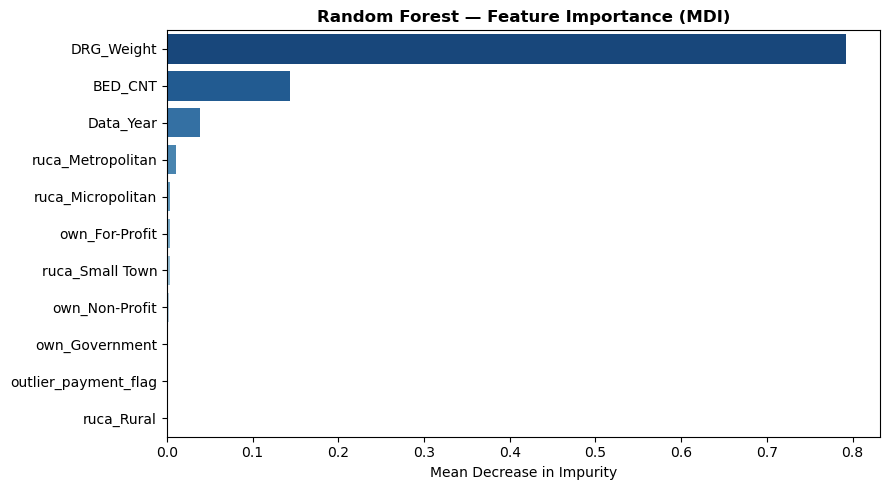

             Feature  Importance
          DRG_Weight    0.792270
             BED_CNT    0.143129
           Data_Year    0.038895
   ruca_Metropolitan    0.010121
   ruca_Micropolitan    0.004064
      own_For-Profit    0.003283
     ruca_Small Town    0.003109
      own_Non-Profit    0.002633
      own_Government    0.001316
outlier_payment_flag    0.000822
          ruca_Rural    0.000359


In [6]:
# ── Random Forest feature importance (MDI) ──
rf_importance = pd.DataFrame({
    'Feature': RQ2_FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='Blues_r', ax=ax)
ax.set_title('Random Forest — Feature Importance (MDI)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(rf_importance.to_string(index=False))

---
## 4.4 XGBoost Regressor

XGBoost typically outperforms Random Forest on tabular data with proper tuning.

In [7]:
# ── XGBoost with early stopping on validation ──
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse',
    early_stopping_rounds=30,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {xgb_model.best_iteration}')
results.append(evaluate('XGBoost', xgb_model, X_train, y_train, 'Train'))
results.append(evaluate('XGBoost', xgb_model, X_val,   y_val,   'Val'))

Best iteration: 999
[Train] XGBoost
  RMSE : 0.5277   MAE: 0.4139 (≈0.5 discharges)   R²: 0.4333
[Val] XGBoost
  RMSE : 0.5303   MAE: 0.4158 (≈0.5 discharges)   R²: 0.4221


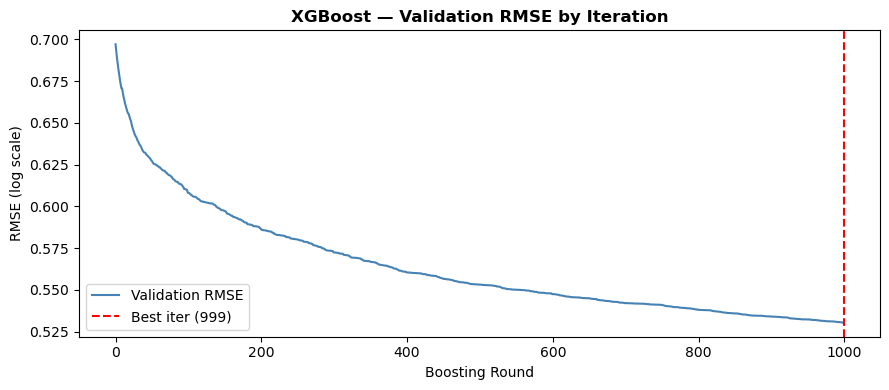

In [8]:
# ── XGBoost learning curve ──
evals_result = xgb_model.evals_result()
train_rmse = evals_result['validation_0']['rmse']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_rmse, color='steelblue', label='Validation RMSE')
ax.axvline(xgb_model.best_iteration, color='red', linestyle='--', label=f'Best iter ({xgb_model.best_iteration})')
ax.set_title('XGBoost — Validation RMSE by Iteration', fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

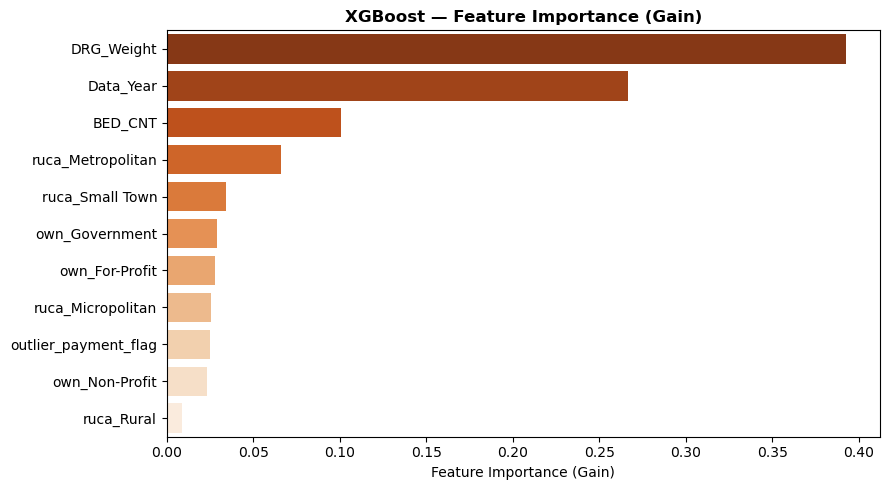

             Feature  Importance
          DRG_Weight    0.392710
           Data_Year    0.266501
             BED_CNT    0.100609
   ruca_Metropolitan    0.065948
     ruca_Small Town    0.034137
      own_Government    0.029135
      own_For-Profit    0.028091
   ruca_Micropolitan    0.025681
outlier_payment_flag    0.024665
      own_Non-Profit    0.023476
          ruca_Rural    0.009048


In [9]:
# ── XGBoost feature importance ──
xgb_importance = pd.DataFrame({
    'Feature': RQ2_FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='Oranges_r', ax=ax)
ax.set_title('XGBoost — Feature Importance (Gain)', fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(xgb_importance.to_string(index=False))

---
## 4.5 Model Comparison

In [10]:
# ── Comparison table — validation results only ──
results_df = pd.DataFrame(results)
val_results = results_df[results_df['Split'] == 'Val'].copy()
val_results = val_results.sort_values('R2', ascending=False).reset_index(drop=True)
val_results['MAE (discharges)'] = np.expm1(val_results['MAE']).round(1)

print('=== Validation Set Comparison ===')
print(val_results[['Model', 'RMSE', 'MAE', 'MAE (discharges)', 'R2']].to_string(index=False))

=== Validation Set Comparison ===
            Model     RMSE      MAE  MAE (discharges)       R2
          XGBoost 0.530306 0.415813               0.5 0.422145
    Random Forest 0.625666 0.497535               0.6 0.195638
Linear Regression 0.691200 0.540186               0.7 0.018312


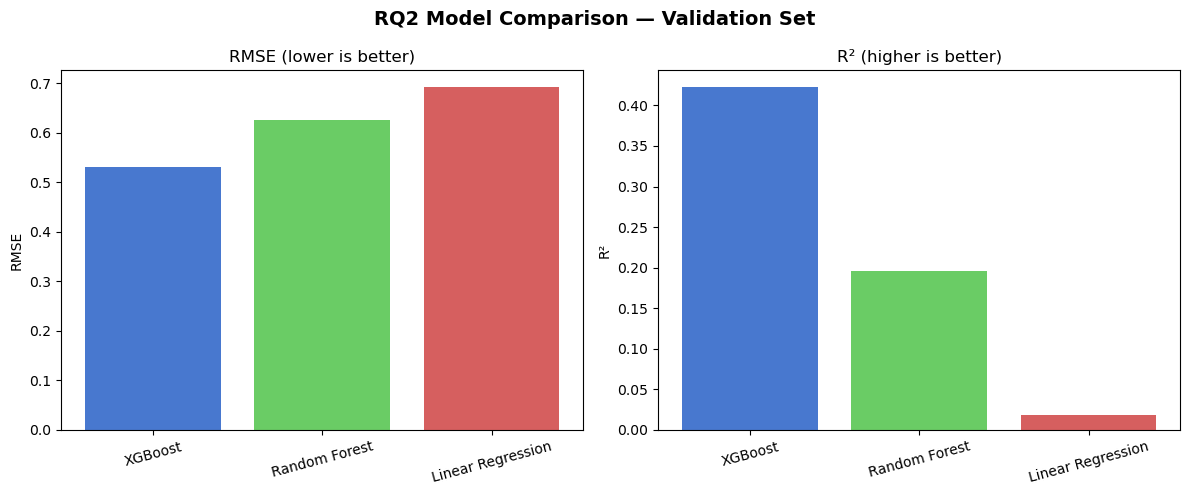

In [11]:
# ── Side-by-side bar chart: RMSE and R² across models ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('RQ2 Model Comparison — Validation Set', fontsize=14, fontweight='bold')

colors = ['#4878CF', '#6ACC65', '#D65F5F']

axes[0].bar(val_results['Model'], val_results['RMSE'], color=colors[:len(val_results)])
axes[0].set_title('RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(val_results['Model'], val_results['R2'], color=colors[:len(val_results)])
axes[1].set_title('R² (higher is better)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

---
## 4.6 Feature Importance & SHAP Analysis

SHAP (SHapley Additive exPlanations) gives us model-agnostic, consistent feature attributions that are directly interpretable.

In [12]:
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('shap not installed. Run: pip install shap')
    print('Skipping SHAP analysis — using built-in feature importance instead.')

if SHAP_AVAILABLE:
    # Use a sample for speed (SHAP on 820k rows is slow)
    X_shap = X_val.sample(5000, random_state=42)

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('SHAP Analysis — XGBoost (RQ2)', fontsize=14, fontweight='bold')

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False)
    axes[0].set_title('Mean |SHAP| — Global Importance')

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_shap, show=False)
    axes[1].set_title('SHAP Beeswarm — Feature Direction & Magnitude')

    plt.tight_layout()
    plt.show()

shap not installed. Run: pip install shap
Skipping SHAP analysis — using built-in feature importance instead.


---
## 4.7 Final Evaluation on Test Set

Run the best model **once** on the held-out test set. We pick the best model based on validation R².

In [13]:
# ── Pick best model from validation ──
best_model_name = val_results.iloc[0]['Model']
model_map = {
    'Linear Regression': lr,
    'Random Forest':     rf,
    'XGBoost':           xgb_model
}
best_model = model_map[best_model_name]
print(f'Best model (by Val R²): {best_model_name}')

# ── Final test set evaluation ──
test_result = evaluate(best_model_name, best_model, X_test, y_test, 'Test')
results.append(test_result)

Best model (by Val R²): XGBoost
[Test] XGBoost
  RMSE : 0.5309   MAE: 0.4160 (≈0.5 discharges)   R²: 0.4268


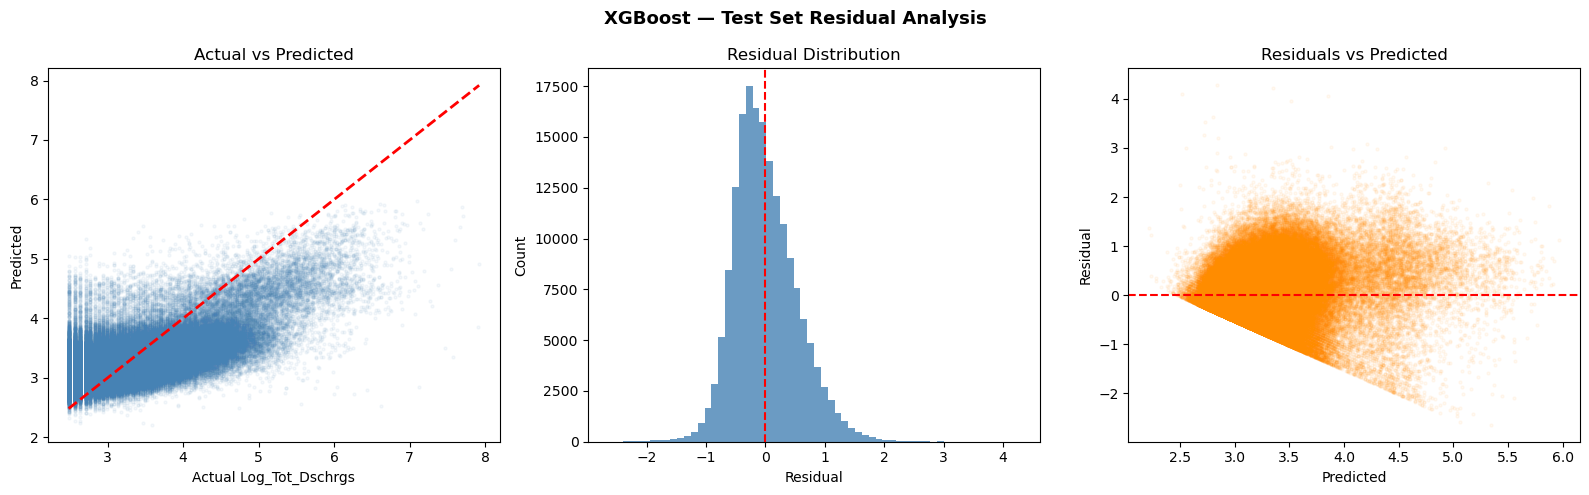

In [14]:
# ── Residual analysis on test set ──
y_pred_test = best_model.predict(X_test)
residuals   = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'{best_model_name} — Test Set Residual Analysis', fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.05, s=5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Log_Tot_Dschrgs')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

# Residual distribution
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

# Residuals vs Predicted
axes[2].scatter(y_pred_test, residuals, alpha=0.05, s=5, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

In [15]:
# ── Error by ownership type ──
test_eval_df = df_test[['Ownership_Type', 'RUCA_Group']].copy()
test_eval_df['actual']    = y_test.values
test_eval_df['predicted'] = y_pred_test
test_eval_df['abs_error'] = np.abs(test_eval_df['actual'] - test_eval_df['predicted'])

print('=== Mean Absolute Error by Ownership Type ===')
print(test_eval_df.groupby('Ownership_Type')['abs_error'].agg(['mean', 'median']).round(4))

print('\n=== Mean Absolute Error by RUCA Group ===')
print(test_eval_df.groupby('RUCA_Group')['abs_error'].agg(['mean', 'median']).round(4))

=== Mean Absolute Error by Ownership Type ===
                  mean  median
Ownership_Type                
For-Profit      0.4214  0.3537
Government      0.4120  0.3426
Non-Profit      0.3958  0.3285

=== Mean Absolute Error by RUCA Group ===
                mean  median
RUCA_Group                  
Metropolitan  0.4236  0.3554
Micropolitan  0.3550  0.2952
Rural         0.3468  0.2896
Small Town    0.3456  0.2696


---
## 4.8 Business Insights

> Fill in after running the notebook — update with actual model results

In [16]:
# ── Final summary table ──
final_df = pd.DataFrame(results)
final_df['MAE (discharges)'] = np.expm1(final_df['MAE']).round(1)
print('=== RQ2 Full Results Summary ===')
print(final_df[['Model', 'Split', 'RMSE', 'MAE', 'MAE (discharges)', 'R2']]
      .sort_values(['Model', 'Split'])
      .to_string(index=False))

=== RQ2 Full Results Summary ===
            Model Split     RMSE      MAE  MAE (discharges)       R2
Linear Regression Train 0.694138 0.541637               0.7 0.019530
Linear Regression   Val 0.691200 0.540186               0.7 0.018312
    Random Forest Train 0.624769 0.496650               0.6 0.205706
    Random Forest   Val 0.625666 0.497535               0.6 0.195638
          XGBoost  Test 0.530943 0.415997               0.5 0.426768
          XGBoost Train 0.527740 0.413860               0.5 0.433261
          XGBoost   Val 0.530306 0.415813               0.5 0.422145
